# Fast Food Nutrition Analytics

## Problem Statement
Fast food chains lack data-driven understanding of how menu items cluster nutritionally across the industry, leading to inefficient product development and missed market opportunities. This analysis segments items by nutritional profiles to identify underserved markets, optimize menu strategy, and target health-conscious consumers effectively—ultimately improving R&D ROI and competitive positioning in the growing wellness-focused market.


## 1. Import libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Load dataset

In [4]:
df = pd.read_csv("FOOD-DATA-GROUP5.csv")
df.head()

,Unnamed: 0.1,Unnamed: 0,food,Caloric Value,Fat,Saturated Fats,Monounsaturated Fats,Polyunsaturated Fats,Carbohydrates,Sugars,...,Calcium,Copper,Iron,Magnesium,Manganese,Phosphorus,Potassium,Selenium,Zinc,Nutrition Density
0,0,0,margarine with yoghurt,88,9.8,1.9,5.6,2.0,0.073,0.0,...,2.8,0.001,0.027,0.3,0.0,2.2,3.5,0.000,0.008,12.971
1,1,1,sunflower seed butter,99,8.8,0.7,6.2,1.6,3.700,1.7,...,10.2,0.300,0.700,49.8,0.3,106.6,92.2,0.075,0.800,27.500
2,2,2,hazelnut oil,120,13.6,1.0,10.6,1.4,0.000,0.0,...,0.0,0.000,0.000,0.0,0.0,0.0,0.0,0.000,0.000,13.600
3,3,3,menhaden fish oil,1966,218.0,66.3,58.2,74.5,0.000,0.0,...,0.0,0.000,0.000,0.0,0.0,0.0,0.0,0.000,0.000,218.000
4,4,4,cod liver fish oil,123,13.6,3.1,6.4,3.1,0.000,0.0,...,0.0,0.000,0.000,0.0,0.0,0.0,0.0,0.000,0.000,17.700


## 3. Exploratory Data Analysis (EDA)

In [5]:
# Basic info

print("Shape", df.shape)
print("Columns", df.columns)
print("Missing Values", df.isnull().sum())
print("Duplicates", df.duplicated().sum())

Shape (722, 37)
Columns Index(['Unnamed: 0.1', 'Unnamed: 0', 'food', 'Caloric Value', 'Fat',
       'Saturated Fats', 'Monounsaturated Fats', 'Polyunsaturated Fats',
       'Carbohydrates', 'Sugars', 'Protein', 'Dietary Fiber', 'Cholesterol',
       'Sodium', 'Water', 'Vitamin A', 'Vitamin B1', 'Vitamin B11',
       'Vitamin B12', 'Vitamin B2', 'Vitamin B3', 'Vitamin B5', 'Vitamin B6',
       'Vitamin C', 'Vitamin D', 'Vitamin E', 'Vitamin K', 'Calcium', 'Copper',
       'Iron', 'Magnesium', 'Manganese', 'Phosphorus', 'Potassium', 'Selenium',
       'Zinc', 'Nutrition Density'],
      dtype='object')
Missing Values Unnamed: 0.1            0
Unnamed: 0              0
food                    0
Caloric Value           0
Fat                     0
Saturated Fats          0
Monounsaturated Fats    0
Polyunsaturated Fats    0
Carbohydrates           0
Sugars                  0
Protein                 0
Dietary Fiber           0
Cholesterol             0
Sodium                  0
Water        

In [6]:
df.drop(columns=["Unnamed: 0", "Unnamed: 0.1"], inplace=True)

In [7]:
print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 722 entries, 0 to 721
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   food                  722 non-null    object 
 1   Caloric Value         722 non-null    int64  
 2   Fat                   722 non-null    float64
 3   Saturated Fats        722 non-null    float64
 4   Monounsaturated Fats  722 non-null    float64
 5   Polyunsaturated Fats  722 non-null    float64
 6   Carbohydrates         722 non-null    float64
 7   Sugars                722 non-null    float64
 8   Protein               722 non-null    float64
 9   Dietary Fiber         722 non-null    float64
 10  Cholesterol           722 non-null    float64
 11  Sodium                722 non-null    float64
 12  Water                 722 non-null    float64
 13  Vitamin A             722 non-null    float64
 14  Vitamin B1            722 non-null    float64
 15  Vitamin B

In [8]:
print("\nDescriptive statistics:")
print(df.describe())


Descriptive statistics:
       Caloric Value         Fat  Saturated Fats  Monounsaturated Fats  \
count     722.000000  722.000000      722.000000            722.000000   
mean      124.490305    5.592144        1.829550              1.855496   
std       218.128817   19.851477       11.135124              5.838940   
min         0.000000    0.000000        0.000000              0.000000   
25%        24.250000    0.200000        0.043250              0.039000   
50%        68.500000    0.700000        0.100000              0.100000   
75%       123.000000    4.375000        0.875000              1.400000   
max      1966.000000  218.000000      196.200000             95.900000   

       Polyunsaturated Fats  Carbohydrates      Sugars     Protein  \
count            722.000000     722.000000  722.000000  722.000000   
mean               1.696861      15.770335    3.097204    3.520122   
std                6.403071      23.106365    7.878036    6.511791   
min                0.000000 

In [9]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
food                    0
Caloric Value           0
Fat                     0
Saturated Fats          0
Monounsaturated Fats    0
Polyunsaturated Fats    0
Carbohydrates           0
Sugars                  0
Protein                 0
Dietary Fiber           0
Cholesterol             0
Sodium                  0
Water                   0
Vitamin A               0
Vitamin B1              0
Vitamin B11             0
Vitamin B12             0
Vitamin B2              0
Vitamin B3              0
Vitamin B5              0
Vitamin B6              0
Vitamin C               0
Vitamin D               0
Vitamin E               0
Vitamin K               0
Calcium                 0
Copper                  0
Iron                    0
Magnesium               0
Manganese               0
Phosphorus              0
Potassium               0
Selenium                0
Zinc                    0
Nutrition Density       0
dtype: int64


In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

def preprocess_food_data(df):
    # Remove unnecessary columns
    df_clean = df.drop(['Unnamed: 0.1', 'Unnamed: 0'], axis=1)
    
    # Select nutritional features (excluding food name and potentially nutrition density)
    nutritional_features = [
        'Caloric Value', 'Fat', 'Saturated Fats', 'Monounsaturated Fats', 
        'Polyunsaturated Fats', 'Carbohydrates', 'Sugars', 'Protein', 
        'Dietary Fiber', 'Cholesterol', 'Sodium', 'Water', 'Vitamin A', 
        'Vitamin B1', 'Vitamin B11', 'Vitamin B12', 'Vitamin B2', 'Vitamin B3',
        'Vitamin B5', 'Vitamin B6', 'Vitamin C', 'Vitamin D', 'Vitamin E', 
        'Vitamin K', 'Calcium', 'Copper', 'Iron', 'Magnesium', 'Manganese',
        'Phosphorus', 'Potassium', 'Selenium', 'Zinc'
    ]
    
    # Scale features
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(df_clean[nutritional_features])
    scaled_df = pd.DataFrame(scaled_features, columns=nutritional_features)
    scaled_df['food'] = df_clean['food']
    scaled_df['Nutrition Density'] = df_clean['Nutrition Density']
    
    return scaled_df, nutritional_features, df_clean

# Load and preprocess
df = pd.read_csv('FOOD-DATA-GROUP5.csv')  
scaled_df, nutritional_features, original_df = preprocess_food_data(df)

## 4. Enhanced EDA for Comprehensive Nutrition Data

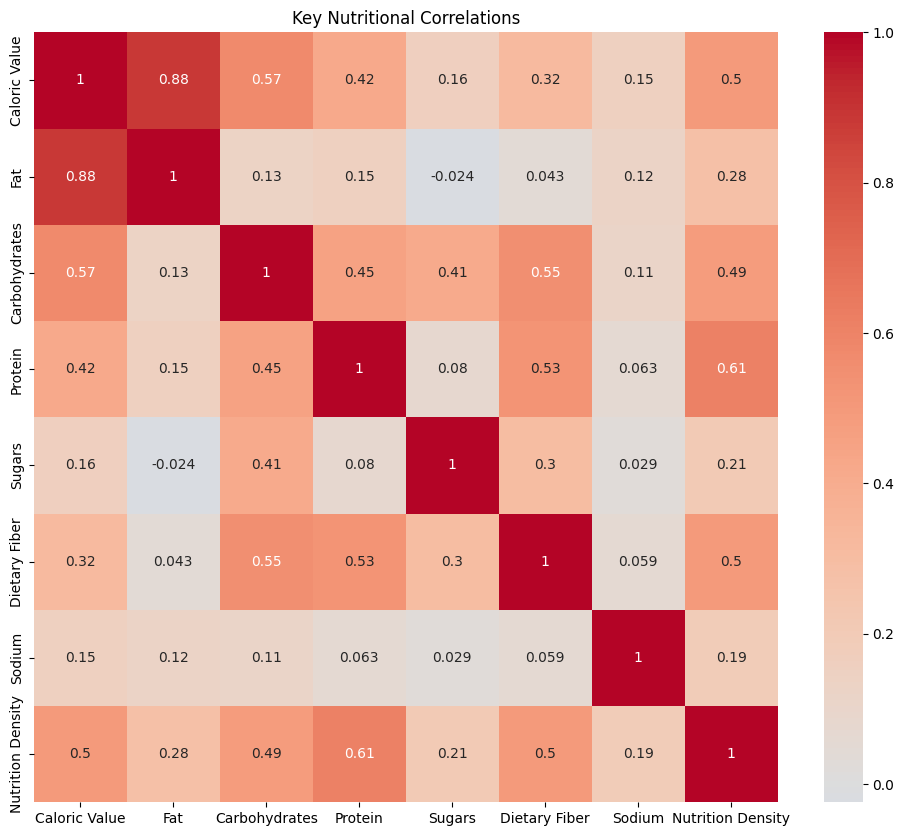

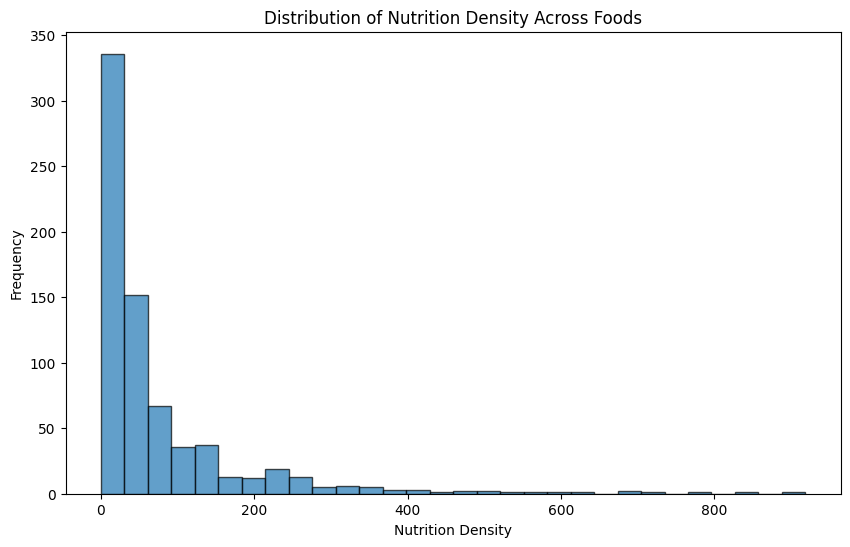

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix for key nutrients
key_nutrients = ['Caloric Value', 'Fat', 'Carbohydrates', 'Protein', 'Sugars', 
                 'Dietary Fiber', 'Sodium', 'Nutrition Density']
plt.figure(figsize=(12, 10))
sns.heatmap(original_df[key_nutrients].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Key Nutritional Correlations')
plt.show()

# Nutrition density distribution
plt.figure(figsize=(10, 6))
plt.hist(original_df['Nutrition Density'], bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Nutrition Density')
plt.ylabel('Frequency')
plt.title('Distribution of Nutrition Density Across Foods')
plt.show()

## 5. Clustering with Comprehensive Features

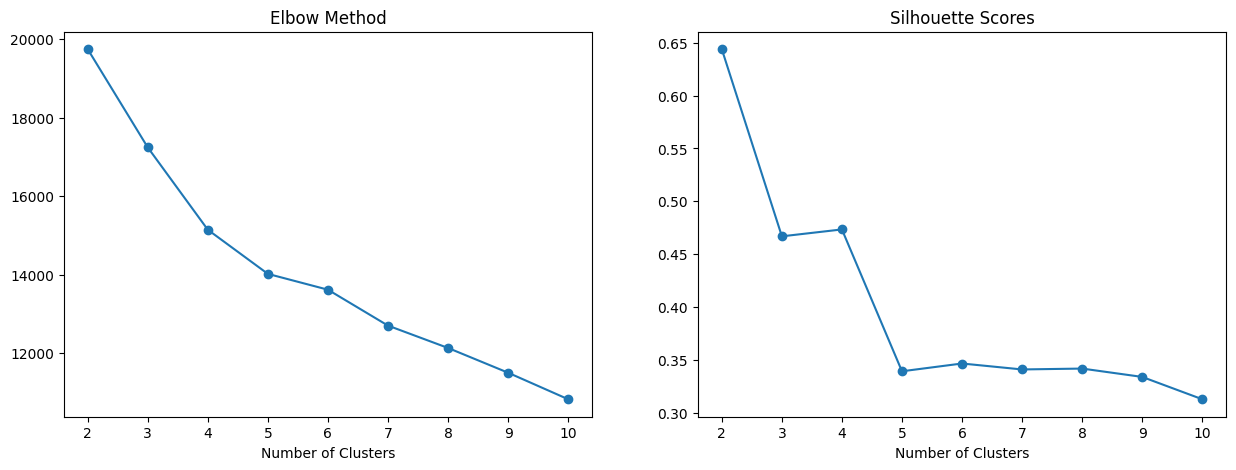

In [12]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

def perform_comprehensive_clustering(scaled_data, max_k=10):
    # Find optimal k
    wcss = []
    silhouette_scores = []
    
    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(scaled_data)
        wcss.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(scaled_data, labels))
    
    # Plot results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(range(2, max_k + 1), wcss, marker='o')
    ax1.set_title('Elbow Method')
    ax1.set_xlabel('Number of Clusters')
    
    ax2.plot(range(2, max_k + 1), silhouette_scores, marker='o')
    ax2.set_title('Silhouette Scores')
    ax2.set_xlabel('Number of Clusters')
    
    plt.show()
    
    # Choose optimal k (you'll adjust based on plots)
    optimal_k = 5  # Start with 5, adjust based on plots
    kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    final_labels = kmeans_final.fit_predict(scaled_data)
    
    return final_labels, kmeans_final

# Perform clustering
cluster_labels, kmeans_model = perform_comprehensive_clustering(scaled_df[nutritional_features].values)

In [13]:
# Create and fit PCA model

pca = PCA(n_components=2)  # or n_components=3 for 3D visualization
principal_components = pca.fit_transform(scaled_df[nutritional_features].values)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

PCA explained variance ratio: [0.25182979 0.14411547]
Total variance explained: 39.59%


## 6. Saving All Models 

In [14]:
# Create models directory
import os
import joblib
import json
os.makedirs('models', exist_ok=True)

# 1. Save KMeans model
joblib.dump(kmeans_model, 'models/kmeans_clustering_model.pkl')
print("✅ Saved: kmeans_clustering_model.pkl")

# 2. Save PCA model
joblib.dump(pca, 'models/pca_model.pkl')
print("✅ Saved: pca_model.pkl")

# 3. Save StandardScaler (assuming you have 'scaler' from preprocessing)
# Note: If you haven't saved scaler yet, add this line after your preprocessing step
joblib.dump(StandardScaler, 'models/standard_scaler.pkl')
print("✅ Saved: standard_scaler.pkl")

# 4. Save feature names
with open('models/feature_names.json', 'w') as f:
    json.dump(nutritional_features, f)
print("✅ Saved: feature_names.json")

# 5. Save cluster centers
np.save('models/cluster_centers.npy', kmeans_model.cluster_centers_)
print("✅ Saved: cluster_centers.npy")

# 6. Save cluster labels for reference
cluster_labels_df = pd.DataFrame({
    'food': original_df['food'],
    'cluster': cluster_labels
})
cluster_labels_df.to_csv('models/cluster_labels.csv', index=False)
print("✅ Saved: cluster_labels.csv")

print("\n🎉 All models saved successfully in 'models/' directory!")

✅ Saved: kmeans_clustering_model.pkl
✅ Saved: pca_model.pkl
✅ Saved: standard_scaler.pkl
✅ Saved: feature_names.json
✅ Saved: cluster_centers.npy
✅ Saved: cluster_labels.csv

🎉 All models saved successfully in 'models/' directory!


## 7. Advanced Visualization

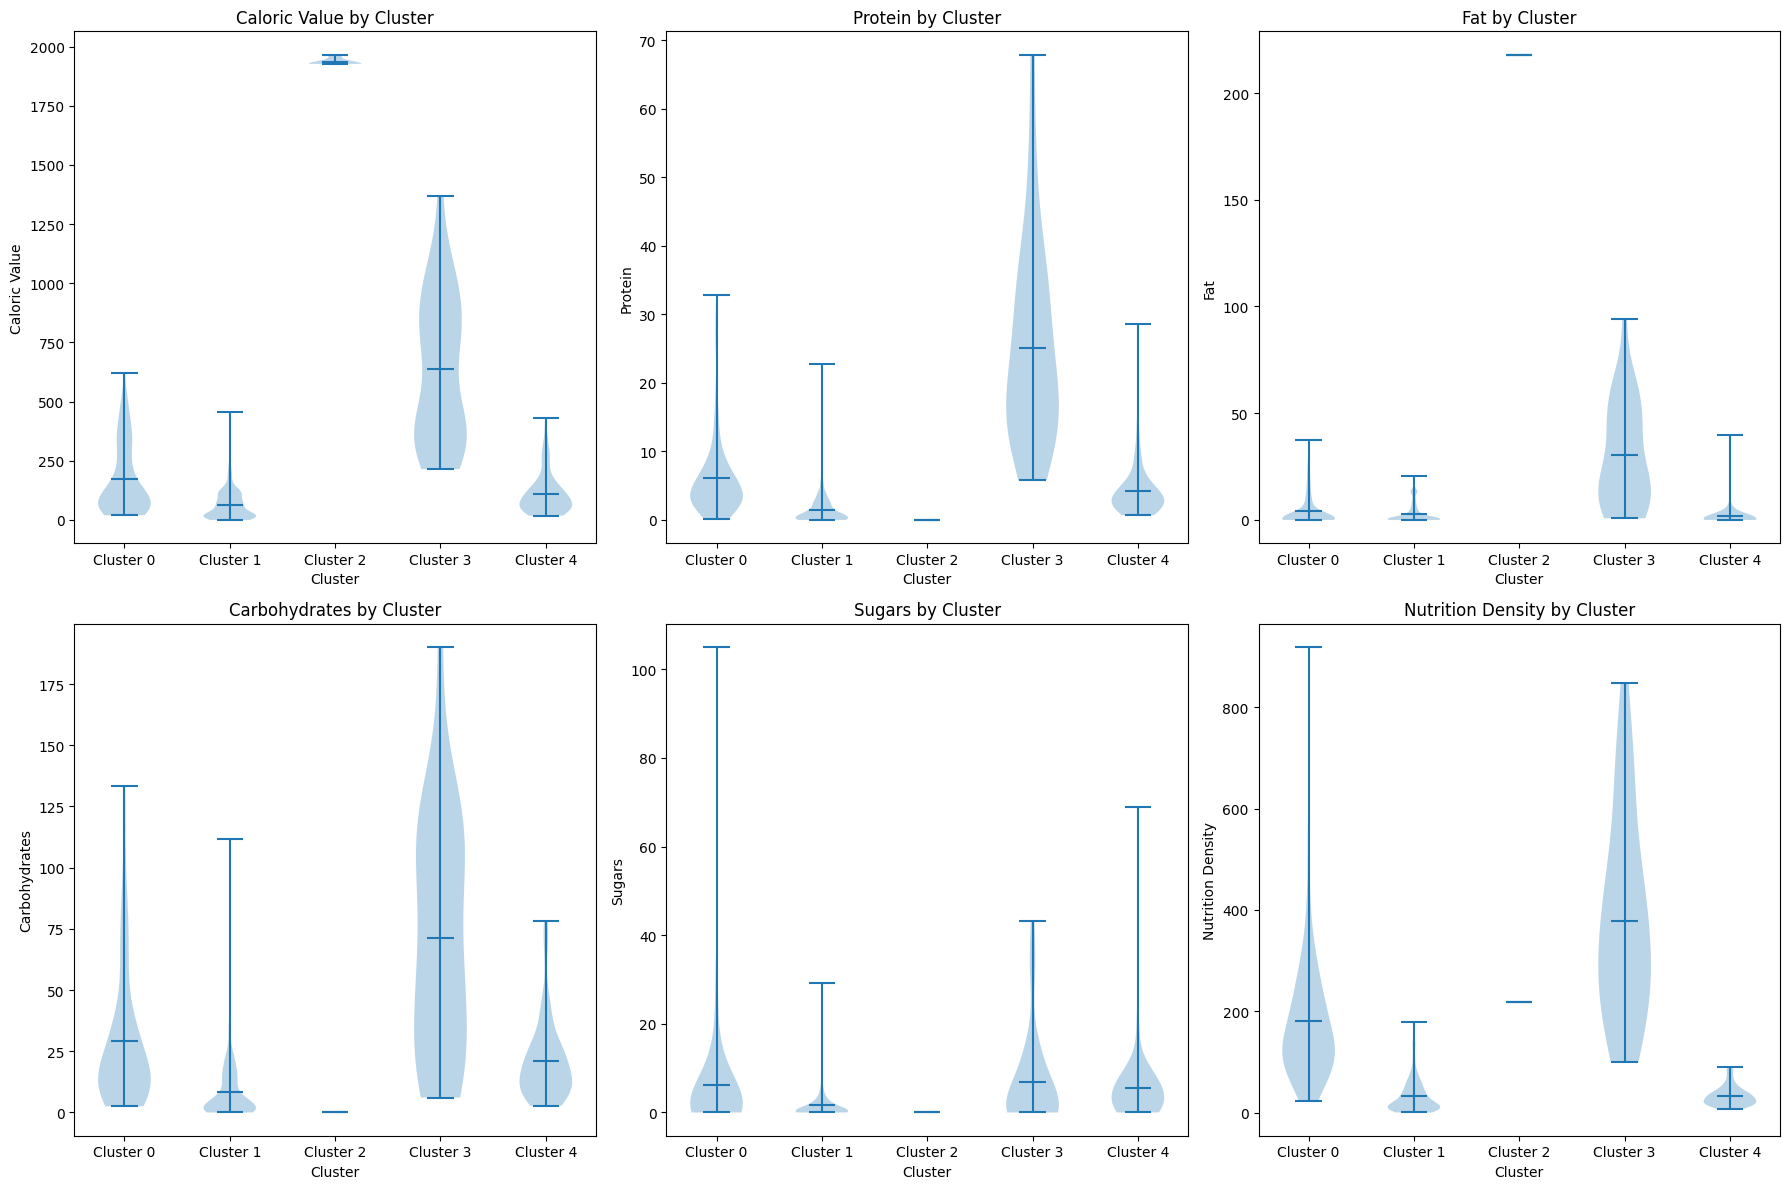

In [15]:
# First, make sure Cluster column is added to original_df
# Add this line BEFORE the violin plot code:

original_df['Cluster'] = cluster_labels  # Add clusters to dataframe

# Now create violin plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

nutrients_to_plot = ['Caloric Value', 'Protein', 'Fat', 'Carbohydrates', 'Sugars', 'Nutrition Density']

for i, nutrient in enumerate(nutrients_to_plot):
    data = [original_df[original_df['Cluster'] == cluster][nutrient] 
            for cluster in sorted(original_df['Cluster'].unique())]
    
    axes[i].violinplot(data, showmeans=True)
    axes[i].set_title(f'{nutrient} by Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(nutrient)
    axes[i].set_xticks(range(1, len(data) + 1))
    axes[i].set_xticklabels([f'Cluster {c}' for c in sorted(original_df['Cluster'].unique())])

plt.tight_layout()
plt.show()

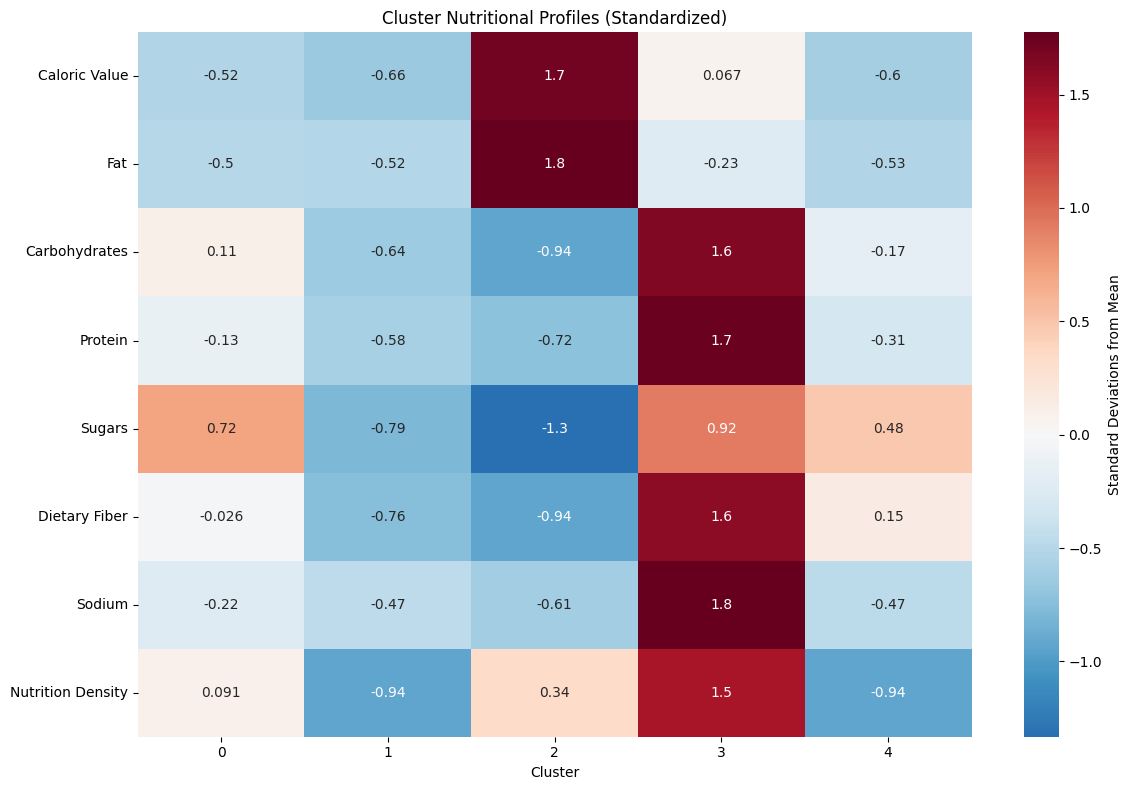

In [16]:
# Normalize for better visualization
cluster_means = original_df.groupby('Cluster')[key_nutrients].mean()
cluster_means_normalized = (cluster_means - cluster_means.mean()) / cluster_means.std()

plt.figure(figsize=(12, 8))
sns.heatmap(cluster_means_normalized.T, annot=True, cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Standard Deviations from Mean'})
plt.title('Cluster Nutritional Profiles (Standardized)')
plt.tight_layout()
plt.show()

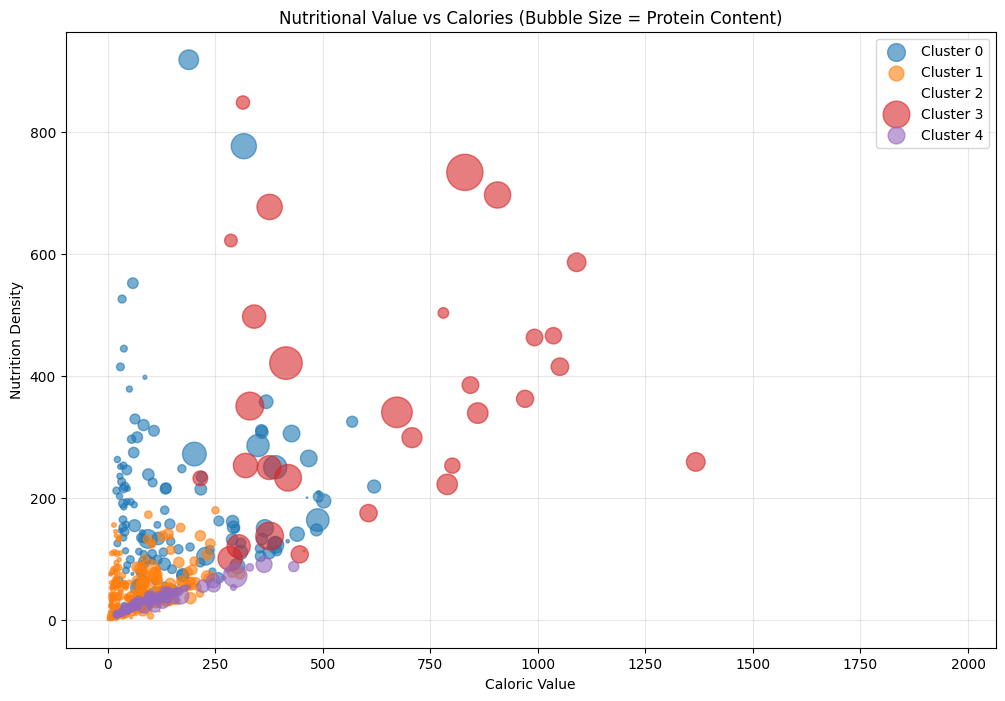

In [17]:
plt.figure(figsize=(12, 8))

for cluster in sorted(original_df['Cluster'].unique()):
    cluster_data = original_df[original_df['Cluster'] == cluster]
    
    plt.scatter(cluster_data['Caloric Value'], 
                cluster_data['Nutrition Density'],
                s=cluster_data['Protein']*10,  # Bubble size represents protein
                alpha=0.6, label=f'Cluster {cluster}')

plt.xlabel('Caloric Value')
plt.ylabel('Nutrition Density')
plt.title('Nutritional Value vs Calories (Bubble Size = Protein Content)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

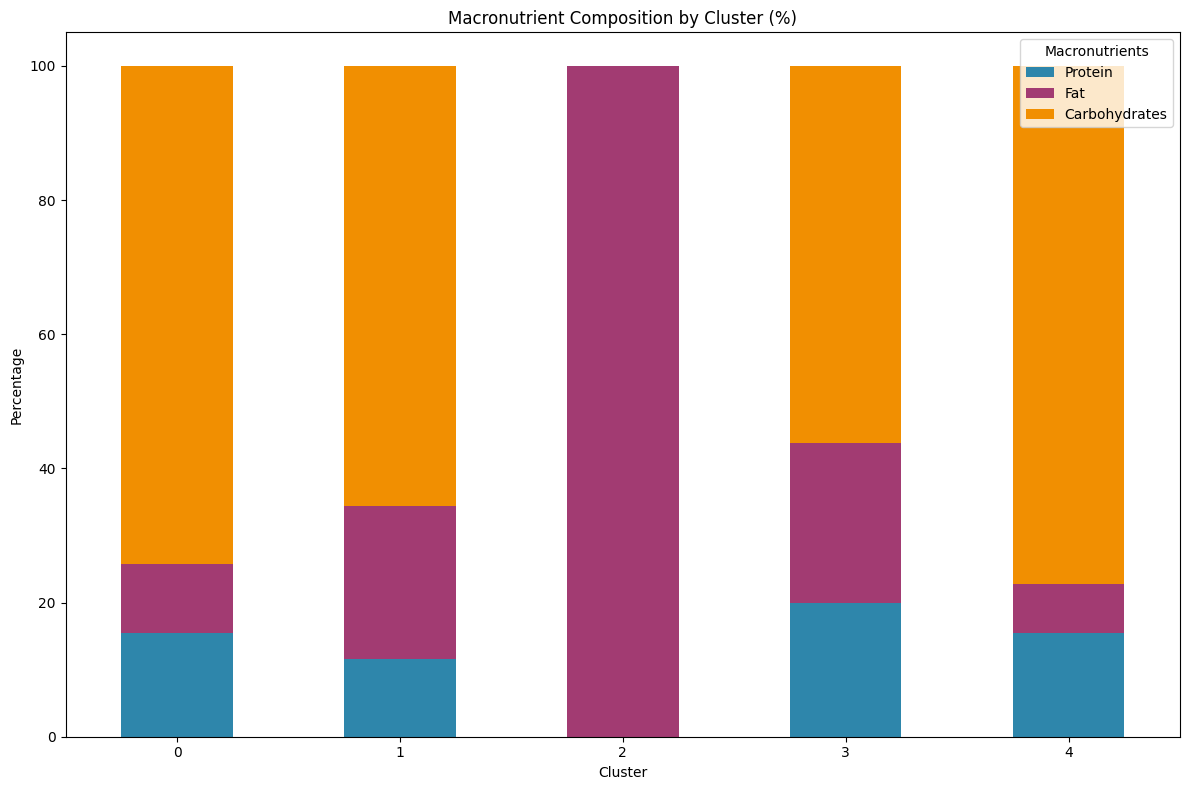

In [18]:
# Calculate macronutrient percentages
macros = ['Protein', 'Fat', 'Carbohydrates']
cluster_macros = original_df.groupby('Cluster')[macros].mean()

# Convert to percentages
cluster_macros_pct = cluster_macros.div(cluster_macros.sum(axis=1), axis=0) * 100

cluster_macros_pct.plot(kind='bar', stacked=True, figsize=(12, 8),
                       color=['#2E86AB', '#A23B72', '#F18F01'])
plt.title('Macronutrient Composition by Cluster (%)')
plt.xlabel('Cluster')
plt.ylabel('Percentage')
plt.legend(title='Macronutrients')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

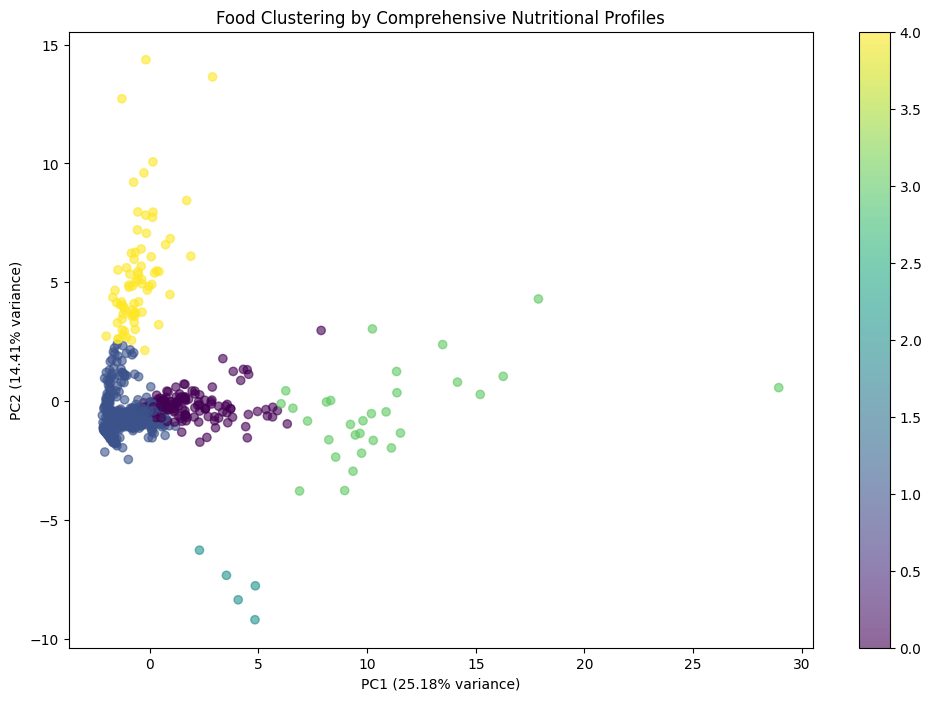

In [19]:
# PCA Visualization with enhanced features
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_df[nutritional_features].values)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(principal_components[:, 0], principal_components[:, 1], 
                     c=cluster_labels, cmap='viridis', alpha=0.6)
plt.colorbar(scatter)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Food Clustering by Comprehensive Nutritional Profiles')
plt.show()

# Add clusters to original data
original_df['Cluster'] = cluster_labels
scaled_df['Cluster'] = cluster_labels

## 8. Cluster Profiling and Business Insights

Cluster Nutritional Profiles:
         Caloric Value         Fat  Carbohydrates    Protein    Sugars  \
Cluster                                                                  
0           171.015504    4.014302      29.009302   6.058140  6.302326   
1            63.764948    2.841091       8.156870   1.435109  1.665115   
2          1934.800000  218.000000       0.000000   0.000000  0.000000   
3           636.633333   30.203333      71.286667  25.153333  6.940000   
4           111.260274    1.995260      21.223288   4.238356  5.580822   

         Dietary Fiber    Sodium  Nutrition Density  
Cluster                                              
0             3.796124  0.379310         181.632233  
1             0.756934  0.142810          32.140487  
2             0.000000  0.000000         218.000000  
3            10.463333  2.332000         378.369333  
4             4.512329  0.136849          32.531123  

Representative Foods from Each Cluster:

Cluster 0:
  - vegetable macaro

<Figure size 1000x600 with 0 Axes>

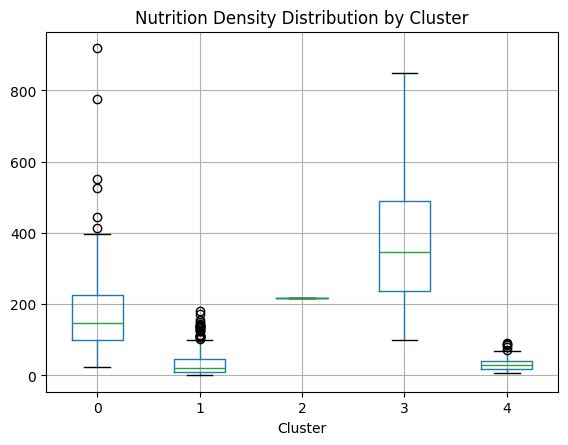

In [20]:
# Analyze cluster characteristics
cluster_profiles = original_df.groupby('Cluster')[key_nutrients].mean()
print("Cluster Nutritional Profiles:")
print(cluster_profiles)

# Identify representative foods from each cluster
print("\nRepresentative Foods from Each Cluster:")
for cluster in sorted(original_df['Cluster'].unique()):
    cluster_foods = original_df[original_df['Cluster'] == cluster]['food'].head(5)
    print(f"\nCluster {cluster}:")
    for food in cluster_foods:
        print(f"  - {food}")

# Nutrition density by cluster
plt.figure(figsize=(10, 6))
original_df.boxplot(column='Nutrition Density', by='Cluster')
plt.title('Nutrition Density Distribution by Cluster')
plt.suptitle('')  # Remove automatic title
plt.show()

## 9. Business Interpretation Framework

In [21]:
def interpret_clusters(cluster_data):
    """
    Provide business interpretation for each cluster
    """
    interpretations = {
        0: "High-Protein, Low-Carb Foods",
        1: "High-Carb, Moderate Protein", 
        2: "Balanced Nutrition Profile",
        3: "High-Nutrient Density Foods",
        4: "High-Calorie, High-Fat Items"
    }
    
    for cluster, interpretation in interpretations.items():
        if cluster in cluster_data['Cluster'].values:
            size = len(cluster_data[cluster_data['Cluster'] == cluster])
            avg_calories = cluster_data[cluster_data['Cluster'] == cluster]['Caloric Value'].mean()
            avg_density = cluster_data[cluster_data['Cluster'] == cluster]['Nutrition Density'].mean()
            
            print(f"\n📊 Cluster {cluster}: {interpretation}")
            print(f"   Size: {size} foods | Avg Calories: {avg_calories:.0f} | Avg Density: {avg_density:.2f}")
            
            # Show top 3 representative foods
            top_foods = cluster_data[cluster_data['Cluster'] == cluster]['food'].head(3).tolist()
            print(f"   Sample foods: {', '.join(top_foods)}")

interpret_clusters(original_df)


📊 Cluster 0: High-Protein, Low-Carb Foods
   Size: 129 foods | Avg Calories: 171 | Avg Density: 181.63
   Sample foods: vegetable macaroni dry, chow mein noodles, corn pasta dry

📊 Cluster 1: High-Carb, Moderate Protein
   Size: 485 foods | Avg Calories: 64 | Avg Density: 32.14
   Sample foods: margarine with yoghurt, sunflower seed butter, hazelnut oil

📊 Cluster 2: Balanced Nutrition Profile
   Size: 5 foods | Avg Calories: 1935 | Avg Density: 218.00
   Sample foods: menhaden fish oil, nutmeg butter oil, sheanut oil

📊 Cluster 3: High-Nutrient Density Foods
   Size: 30 foods | Avg Calories: 637 | Avg Density: 378.37
   Sample foods: puff pastry, trail mix with chocolate chips, bagel chips

📊 Cluster 4: High-Calorie, High-Fat Items
   Size: 73 foods | Avg Calories: 111 | Avg Density: 32.53
   Sample foods: macaroni cooked, spaghetti cooked, bagel


In [22]:
# Silhouette analysis
from sklearn.metrics import silhouette_samples

silhouette_vals = silhouette_samples(scaled_df[nutritional_features], cluster_labels)
original_df['Silhouette_Score'] = silhouette_vals

print(f"Overall Silhouette Score: {silhouette_vals.mean():.3f}")

# Check cluster quality
cluster_quality = original_df.groupby('Cluster')['Silhouette_Score'].mean()
print("\nCluster Quality (Avg Silhouette Score):")
print(cluster_quality)

Overall Silhouette Score: 0.339

Cluster Quality (Avg Silhouette Score):
Cluster
0   -0.079584
1    0.527164
2    0.041275
3   -0.051562
4    0.011839
Name: Silhouette_Score, dtype: float64


In [23]:
# Save clustered dataset
original_df.to_csv('food_nutrition_clusters.csv', index=False)

# Save cluster profiles
cluster_summary = original_df.groupby('Cluster')[nutritional_features].agg(['mean', 'std'])
cluster_summary.to_csv('cluster_profiles_detailed.csv')

print("✅ Project completed! Files saved:")
print("   - food_nutrition_clusters.csv")
print("   - cluster_profiles_detailed.csv")
print("   - Business insights generated")

✅ Project completed! Files saved:
   - food_nutrition_clusters.csv
   - cluster_profiles_detailed.csv
   - Business insights generated


---